In [ ]:
# ============================
# LOAD DATA
# ============================

In [9]:
!git clone https://github.com/ZachSkiba/CSP571-G7.git

import pandas as pd

# adjust file names if needed based on what’s inside processed/
df = pd.read_csv("CSP571-G7/data/processed/binary_train.csv")

# Separate features and target
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

fatal: destination path 'CSP571-G7' already exists and is not an empty directory.
X shape: (202943, 21)
y shape: (202943,)
Diabetes_binary
0    174667
1     28276
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# ============================
# ELBOW METHOD
# ============================
# We use the elbow method to determine the optimal number
# of clusters by plotting inertia for different values of k.

# The elbow appears around k = 3,
# suggesting that three clusters is a reasonable choice for this dataset.

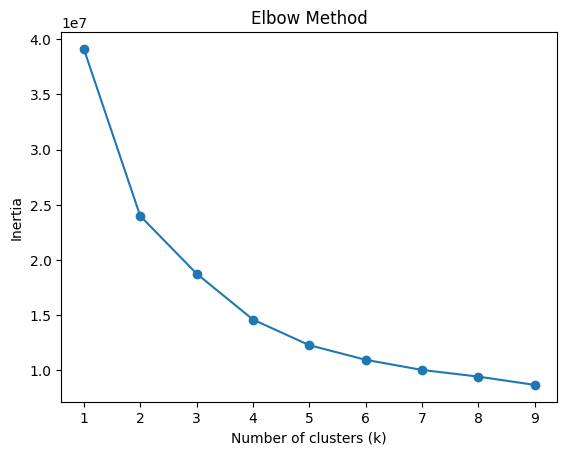

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)  # ✅ use X instead of X_train
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [21]:
# ============================
# K-MEANS CLUSTERING
# ============================
# We run K-Means with k=2 and k=3 to explore how the data
# naturally groups into clusters.

In [22]:
kmeans_2 = KMeans(n_clusters=2, random_state=42)
clusters_2 = kmeans_2.fit_predict(X)

kmeans_3 = KMeans(n_clusters=3, random_state=42)
clusters_3 = kmeans_3.fit_predict(X)

In [23]:
# ============================
# CLUSTER EVALUATION
# ============================
# We use Adjusted Rand Index (ARI) to compare cluster assignments
# with actual diabetes labels. Higher values indicate better alignment.

In [24]:
from sklearn.metrics import adjusted_rand_score

ari_2 = adjusted_rand_score(y, clusters_2)
ari_3 = adjusted_rand_score(y, clusters_3)

print("ARI (k=2):", ari_2)
print("ARI (k=3):", ari_3)

ARI (k=2): 0.10643728174892667
ARI (k=3): 0.0974998554562188


In [25]:
# ============================
# CLUSTER INTERPRETATION
# ============================
# We analyze the average feature values within each cluster
# to understand the characteristics of each group.

In [26]:
X["cluster"] = clusters_3

cluster_means = X.groupby("cluster").mean()
print(cluster_means)

           HighBP  HighChol  CholCheck        BMI    Smoker    Stroke  \
cluster                                                                 
0        0.401593  0.402270   0.961289  28.022874  0.415755  0.030142   
1        0.633927  0.573219   0.978270  30.584610  0.590054  0.117938   
2        0.442280  0.456158   0.951900  29.429191  0.536824  0.047548   

         HeartDiseaseorAttack  PhysActivity    Fruits   Veggies  ...  \
cluster                                                          ...   
0                    0.075634      0.794325  0.647451  0.822864  ...   
1                    0.231163      0.508166  0.582094  0.745734  ...   
2                    0.099511      0.686169  0.553856  0.767387  ...   

         AnyHealthcare  NoDocbcCost   GenHlth   MentHlth   PhysHlth  DiffWalk  \
cluster                                                                         
0             0.954490     0.062196  2.294937   0.862199   1.252610  0.101721   
1             0.947985     0.1

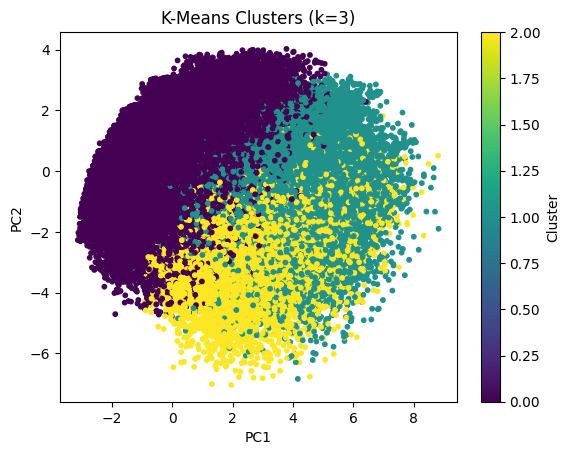

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_3, cmap='viridis', s=10)
plt.title("K-Means Clusters (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
# The elbow appears around k = 3,
# suggesting that three clusters is a reasonable choice for this dataset.

In [ ]:
# The ARI values are relatively low, which is expected
# since K-Means is unsupervised and does not use label information during clustering

In [ ]:
# Cluster 0 appears to represent individuals with lower BMI and healthier lifestyle indicators.
# Cluster 1 shows moderate values across most features.
# Cluster 2 has higher BMI, higher rates of high blood pressure,
# and worse general health, indicating a higher-risk group.